In [1]:
# input
hrk_exp_file = "./data/zn_icp-mass.tsv"
# output
fig_file = "./fig/ted_zn_icp-mass.pdf"

In [2]:
import pandas as pd
import numpy as np

df = pd.read_table(hrk_exp_file)
# df['exp_type'] = df.apply(lambda row: f"{row['seq_id']}_{row['exp_type']}", axis=1)
df['exp_type'] = df.apply(lambda row: f"{row['exp_type']}", axis=1)
data = dict()
for (exp,), df_exp in df.groupby(by=['exp_type']):
    data[exp] = df_exp['ratio'].tolist()

# site-1 mutant: C12A, H15A, C105A and C108A
# site-2 mutant: H20A, C21A and H24A

data
categories = data.keys()
means = [np.mean(data[cat]) for cat in categories]
means
stds = [np.std(data[cat], ddof=1) for cat in categories]

{'WT': [0.280124233826514, 0.283560275896439, 0.280121334392137],
 'all mutant': [0.0309420152924381, 0.0637552115863878, 0.0341542106461957]}

[np.float64(0.28126861470503), np.float64(0.042950479175007196)]

[Text(0, 0, 'WT'), Text(1, 0, 'all mutant')]

(0.0, 0.35)

Text(0, 0.5, 'Ratio in mol (ion / protein)')

(array([0, 1]), [Text(0, 0, 'WT'), Text(1, 0, 'all mutant')])

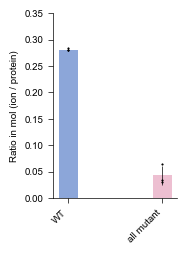

In [8]:
import matplotlib.pyplot as plt


plt.style.use(f"{PROJECT_DIR}/asset/metalnet.mplstyle")
color_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']

fig, ax = plt.subplots(figsize=(1.6, 2.4))

x = np.arange(len(categories))
bar_width = 0.2
bars = ax.bar(x, means, width=bar_width, color=color_cycle, yerr=stds)

for i, cat in enumerate(categories):
    y_vals = data[cat]
    ax.scatter(np.full(len(y_vals), x[i]), y_vals, s=1, c="black")

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.set_ylim(0, 0.35)
ax.set_ylabel("Ratio in mol (ion / protein)")
plt.xticks(rotation=45, ha='right')

fig.savefig(fig_file, bbox_inches="tight", transparent=True)